# 회귀 baseline 비교 - XGBoost / LightGBM (시간당 최대수요전력 값 예측)

`03_xgboost.ipynb` ~ `05_isolation_forest.ipynb`는 문제를 **분류**(피크 위험 0/1)로 풀었다. 이 notebook은 원래 문제인 **회귀**(다음 시점 `target_power` 연속값 예측)로 돌아가, `results/peak_dataset.csv`의 같은 feature·시계열 분할을 그대로 사용해 XGBoost/LightGBM 회귀 모델이 단순 baseline 대비 얼마나 개선되는지 확인한다.

`01_preprocessing.ipynb`(SimpleRNN)와 `02_random_forest.ipynb`(RandomForestRegressor)도 회귀 baseline이지만, **target 정의와 feature 구성이 다르다** (01은 `Peak Consumption in 15 minute` 단일 지표, 02는 15분 단위 4개 지표를 행 단위로 풀어씀). 이 notebook의 target(`target_power` = 시간당 max(15/30/45/60분))과는 직접 비교할 수 없어 참고용으로만 병기한다.

## 1. 라이브러리 / 설정

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

sns.set(style="darkgrid")
plt.rc("font", family="AppleGothic")
plt.rcParams["axes.unicode_minus"] = False

In [2]:
SEED = 42
RESULTS_DIR = Path("../results")

## 2. 03/04/05와 동일한 데이터셋 불러오기

In [3]:
meta = json.loads((RESULTS_DIR / "peak_experiment_meta.json").read_text())
dataset = pd.read_csv(RESULTS_DIR / "peak_dataset.csv", index_col="Date", parse_dates=True)

FEATURES = meta["features"]
assert list(dataset.columns) == FEATURES + ["target_power", "split"]

print(f"dataset {dataset.shape}, features={len(FEATURES)}")

dataset (6000, 32), features=30


## 3. 시계열 분할

03/04/05와 동일한 분할이다 (`peak_dataset.csv`의 `split` 컬럼 재사용). Target은 분류용 라벨이 아니라 **연속값** `target_power`다.

| 구간 | 기간 |
|---|---|
| Train | 2021-01-08 ~ 2021-07-31 |
| Validation | 2021-08-01 ~ 2021-08-31 |
| Test | 2021-09-01 ~ 2021-09-14 |

In [4]:
train_df = dataset.loc[dataset["split"] == "train"]
val_df = dataset.loc[dataset["split"] == "validation"]
test_df = dataset.loc[dataset["split"] == "test"]

assert train_df.index.max() < val_df.index.min() <= val_df.index.max() < test_df.index.min()
assert val_df.index.min() == pd.Timestamp(meta["val_start"]) and test_df.index.min() == pd.Timestamp(meta["test_start"])

X_train, y_train = train_df[FEATURES], train_df["target_power"]
X_val, y_val = val_df[FEATURES], val_df["target_power"]
X_test, y_test = test_df[FEATURES], test_df["target_power"]

print(f"train {X_train.shape}, validation {X_val.shape}, test {X_test.shape}")

train (4920, 30), validation (744, 30), test (336, 30)


## 4. Baseline - Persistence (`lag_1` 그대로 예측)

"직전 시점 전력이 다음 시점에도 그대로 유지된다"는 규칙. 학습 모델이 이 baseline보다 오차가 낮아야 의미가 있다.

In [5]:
def regression_report(y_true, y_pred) -> dict:
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
    }


persistence_val = regression_report(y_val, X_val["lag_1"])
persistence_test = regression_report(y_test, X_test["lag_1"])
print("Persistence validation:", {k: round(v, 3) for k, v in persistence_val.items()})
print("Persistence test      :", {k: round(v, 3) for k, v in persistence_test.items()})

Persistence validation: {'MAE': 11.431, 'MSE': 436.91, 'RMSE': 20.902}
Persistence test      : {'MAE': 14.521, 'MSE': 565.312, 'RMSE': 23.776}


## 5. XGBoost Regressor

validation MAE 기준 소규모 grid search 후, 최적 설정으로 최종 모델을 학습한다.

In [6]:
xgb_param_grid = [
    {"n_estimators": n, "max_depth": d, "learning_rate": lr}
    for n in [300, 600]
    for d in [3, 5]
    for lr in [0.03, 0.05]
]

xgb_search = []
for params in xgb_param_grid:
    model = XGBRegressor(**params, random_state=SEED, n_jobs=-1)
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    xgb_search.append({**params, **regression_report(y_val, val_pred)})

xgb_search = pd.DataFrame(xgb_search)
best_xgb_params = xgb_search.loc[xgb_search["MAE"].idxmin(), ["n_estimators", "max_depth", "learning_rate"]].to_dict()
best_xgb_params["n_estimators"] = int(best_xgb_params["n_estimators"])
best_xgb_params["max_depth"] = int(best_xgb_params["max_depth"])
print(f"선택된 XGBoost 파라미터 (validation MAE 기준): {best_xgb_params}")
xgb_search.sort_values("MAE").round(4)

선택된 XGBoost 파라미터 (validation MAE 기준): {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.03}


,n_estimators,max_depth,learning_rate,MAE,MSE,RMSE
2,300,5,0.03,14.6876,915.8679,30.2633
7,600,5,0.05,14.9188,932.7932,30.5417
6,600,5,0.03,14.9736,940.2637,30.6637
3,300,5,0.05,15.2490,957.0734,30.9366
0,300,3,0.03,16.2621,1030.5140,32.1016
4,600,3,0.03,16.5858,1147.2825,33.8716
1,300,3,0.05,17.0131,1195.6122,34.5776
5,600,3,0.05,17.3505,1294.1193,35.9739


In [7]:
xgb_model = XGBRegressor(**best_xgb_params, random_state=SEED, n_jobs=-1)
xgb_model.fit(X_train, y_train)
xgb_val_pred = xgb_model.predict(X_val)
xgb_test_pred = xgb_model.predict(X_test)

print("XGBoost validation:", {k: round(v, 3) for k, v in regression_report(y_val, xgb_val_pred).items()})
print("XGBoost test      :", {k: round(v, 3) for k, v in regression_report(y_test, xgb_test_pred).items()})

XGBoost validation: {'MAE': 14.688, 'MSE': 915.868, 'RMSE': 30.263}
XGBoost test      : {'MAE': 6.062, 'MSE': 75.967, 'RMSE': 8.716}


## 6. LightGBM Regressor

같은 grid로 validation MAE 기준 탐색 후 최종 모델을 학습한다.

In [8]:
lgbm_param_grid = xgb_param_grid  # 공정한 비교를 위해 동일한 그리드 사용

lgbm_search = []
for params in lgbm_param_grid:
    model = LGBMRegressor(**params, random_state=SEED, n_jobs=-1, verbose=-1)
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    lgbm_search.append({**params, **regression_report(y_val, val_pred)})

lgbm_search = pd.DataFrame(lgbm_search)
best_lgbm_params = lgbm_search.loc[lgbm_search["MAE"].idxmin(), ["n_estimators", "max_depth", "learning_rate"]].to_dict()
best_lgbm_params["n_estimators"] = int(best_lgbm_params["n_estimators"])
best_lgbm_params["max_depth"] = int(best_lgbm_params["max_depth"])
print(f"선택된 LightGBM 파라미터 (validation MAE 기준): {best_lgbm_params}")
lgbm_search.sort_values("MAE").round(4)

선택된 LightGBM 파라미터 (validation MAE 기준): {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.03}


,n_estimators,max_depth,learning_rate,MAE,MSE,RMSE
0,300,3,0.03,11.7421,307.9556,17.5487
5,600,3,0.05,11.8055,337.8435,18.3805
1,300,3,0.05,11.8968,329.0244,18.1390
4,600,3,0.03,11.9487,334.4940,18.2892
2,300,5,0.03,13.8669,592.0817,24.3327
3,300,5,0.05,14.1508,625.2530,25.0051
6,600,5,0.03,14.2527,643.7537,25.3723
7,600,5,0.05,14.6461,661.4576,25.7188


In [9]:
lgbm_model = LGBMRegressor(**best_lgbm_params, random_state=SEED, n_jobs=-1, verbose=-1)
lgbm_model.fit(X_train, y_train)
lgbm_val_pred = lgbm_model.predict(X_val)
lgbm_test_pred = lgbm_model.predict(X_test)

print("LightGBM validation:", {k: round(v, 3) for k, v in regression_report(y_val, lgbm_val_pred).items()})
print("LightGBM test      :", {k: round(v, 3) for k, v in regression_report(y_test, lgbm_test_pred).items()})

LightGBM validation: {'MAE': 11.742, 'MSE': 307.956, 'RMSE': 17.549}
LightGBM test      : {'MAE': 6.654, 'MSE': 99.323, 'RMSE': 9.966}


## 7. Test 평가 - Persistence / XGBoost / LightGBM (동일 target·feature 기준)

세 방법 모두 같은 `target_power`, 같은 feature, 같은 test 구간(2021-09-01~09-14)을 사용하므로 직접 비교 가능하다.

In [10]:
comparison = pd.DataFrame(
    {
        "Persistence (lag_1)": persistence_test,
        "XGBoost": regression_report(y_test, xgb_test_pred),
        "LightGBM": regression_report(y_test, lgbm_test_pred),
    }
).T

comparison["MAE 개선율(vs Persistence)"] = (
    (comparison.loc["Persistence (lag_1)", "MAE"] - comparison["MAE"]) / comparison.loc["Persistence (lag_1)", "MAE"]
)
comparison.round(4)

,MAE,MSE,RMSE,MAE 개선율(vs Persistence)
Persistence (lag_1),14.5208,565.3125,23.7763,0.0000
XGBoost,6.0623,75.9669,8.7159,0.5825
LightGBM,6.6542,99.3234,9.9661,0.5418


### 7-1. 참고 - 01/02의 회귀 baseline (다른 target/feature, 직접 비교 불가)

- `01_preprocessing.ipynb` SimpleRNN: target = `15분`(15분 단위 지표 1개), 같은 test 기간(2021-09-01~09-14). **MSE 220.223 / RMSE 14.840**
- `02_random_forest.ipynb` RandomForestRegressor: target = `평균`, 전력 lag 없이 생산량·기상·달력 피처만 사용, 같은 test 기간. **test MSE 130.820**

두 값 모두 target 정의가 이 notebook의 `target_power`(시간당 4개 지표의 max)와 다르므로 표에 함께 넣지 않고 참고로만 남긴다.

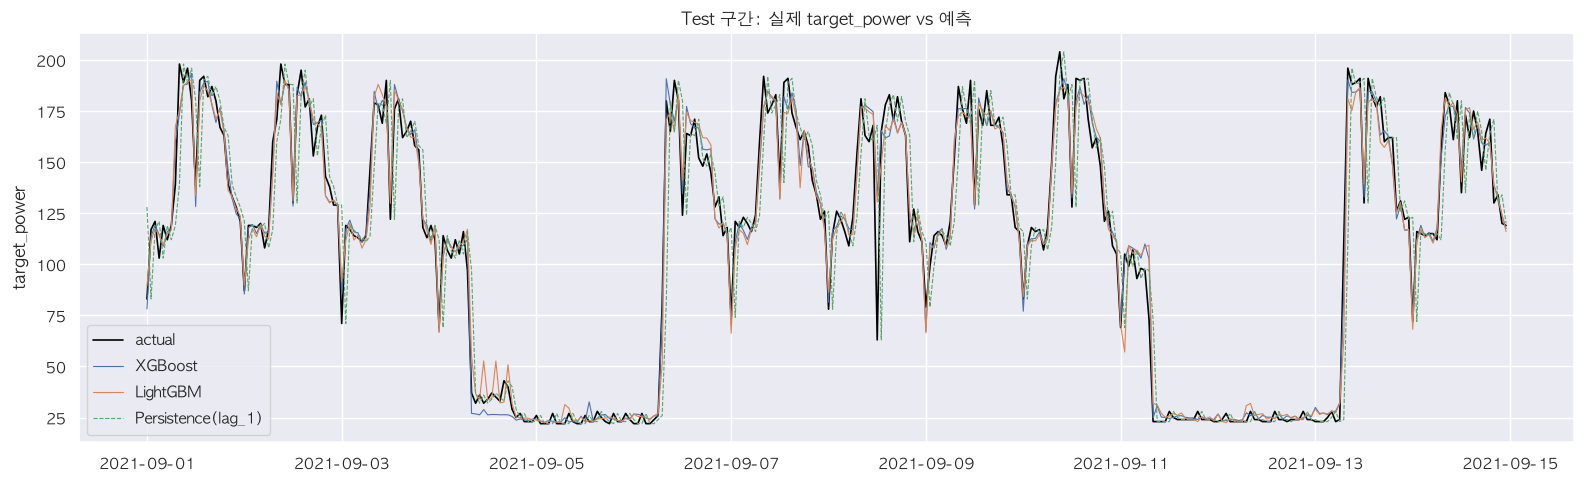

In [11]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test_df.index, y_test, label="actual", linewidth=1.2, color="black")
ax.plot(test_df.index, xgb_test_pred, label="XGBoost", linewidth=0.8)
ax.plot(test_df.index, lgbm_test_pred, label="LightGBM", linewidth=0.8)
ax.plot(test_df.index, X_test["lag_1"], label="Persistence(lag_1)", linewidth=0.8, linestyle="--")
ax.set_title("Test 구간: 실제 target_power vs 예측")
ax.set_ylabel("target_power")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Feature Importance 비교

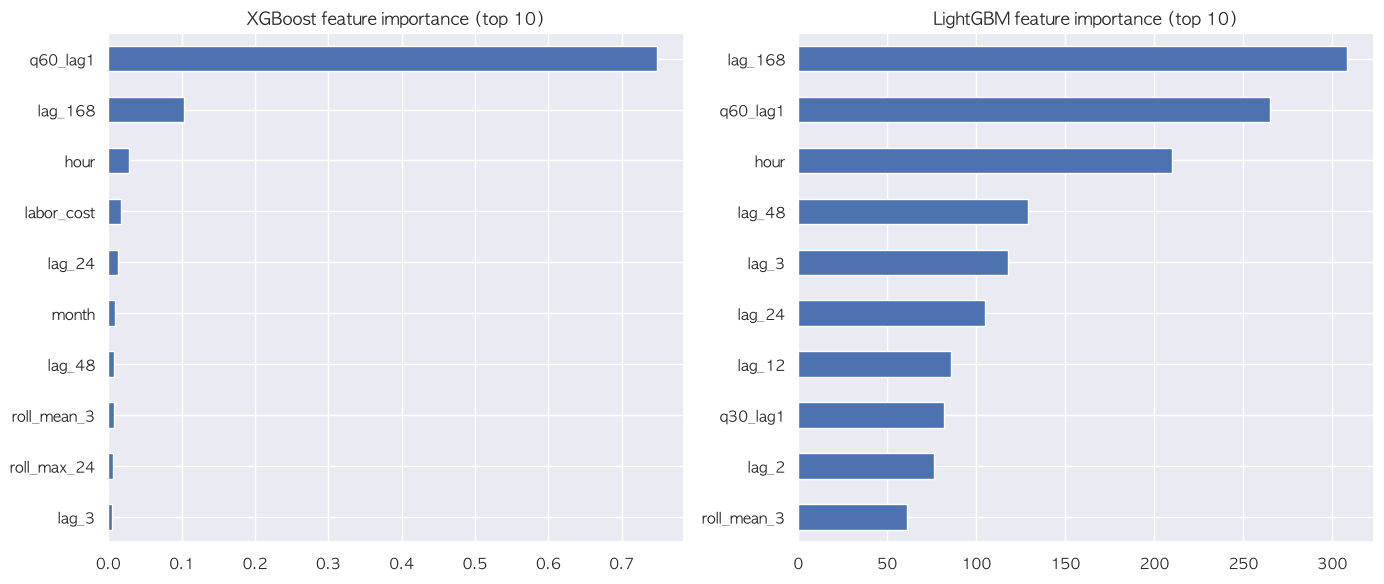

In [12]:
xgb_importance = pd.Series(xgb_model.feature_importances_, index=FEATURES, name="XGBoost").sort_values(ascending=False)
lgbm_importance = pd.Series(lgbm_model.feature_importances_, index=FEATURES, name="LightGBM").sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
xgb_importance.head(10).iloc[::-1].plot.barh(ax=axes[0], title="XGBoost feature importance (top 10)")
lgbm_importance.head(10).iloc[::-1].plot.barh(ax=axes[1], title="LightGBM feature importance (top 10)")
plt.tight_layout()
plt.show()

## 9. 결과 저장

In [13]:
regression_predictions = pd.DataFrame(
    {
        "Date": test_df.index,
        "actual_power": y_test.to_numpy(),
        "persistence_pred": X_test["lag_1"].to_numpy(),
        "xgboost_pred": xgb_test_pred,
        "lightgbm_pred": lgbm_test_pred,
    }
)
regression_predictions.to_csv(RESULTS_DIR / "regression_baselines_predictions.csv", index=False)

comparison.round(4).to_csv(RESULTS_DIR / "regression_baselines_comparison.csv")
comparison.round(4)

,MAE,MSE,RMSE,MAE 개선율(vs Persistence)
Persistence (lag_1),14.5208,565.3125,23.7763,0.0000
XGBoost,6.0623,75.9669,8.7159,0.5825
LightGBM,6.6542,99.3234,9.9661,0.5418


## 10. 최종 요약

In [14]:
best_model = comparison["MAE"].idxmin()
best_mae = comparison.loc[best_model, "MAE"]
improvement = comparison.loc[best_model, "MAE 개선율(vs Persistence)"]

summary_lines = [
    f"Persistence baseline MAE : {comparison.loc['Persistence (lag_1)', 'MAE']:.3f}",
    f"XGBoost MAE              : {comparison.loc['XGBoost', 'MAE']:.3f}",
    f"LightGBM MAE             : {comparison.loc['LightGBM', 'MAE']:.3f}",
    "",
    f"최고 성능 모델: {best_model} (MAE {best_mae:.3f}, Persistence 대비 {improvement:+.1%})",
    "",
    "참고 (target/feature가 달라 직접 비교 불가): 01 SimpleRNN MAE 7.872 / 02 RandomForest MAE 8.582",
]
print("\n".join(summary_lines))

Persistence baseline MAE : 14.521
XGBoost MAE              : 6.062
LightGBM MAE             : 6.654

최고 성능 모델: XGBoost (MAE 6.062, Persistence 대비 +58.3%)

참고 (target/feature가 달라 직접 비교 불가): 01 SimpleRNN MAE 7.872 / 02 RandomForest MAE 8.582
